Realizamos las importaciones de librerías

In [ ]:
# importaciones iniciales

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 

from imblearn.over_sampling import SMOTE

In [ ]:
# Cargamos/leemos el dataset
df = pd.read_csv("../data/creditcard.csv")

#verificamos la carga
df.head()

print(df.columns)

print(df['Class'].value_counts())

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')
Class
0    284315
1       492
Name: count, dtype: int64


Comenzamos con la exploración inicial

Aquí lo que vamos a revisar es:
* Número de columnas.
* Tipos de variables.
* Cantidad de registros.

In [23]:
# revisamos la información general de dataset
df.info()

# revisamos las dimensiones 
df.shape

#miramos las estadísticas generales
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Ahora comenzamos con la limpieza de datos

In [24]:
# buscamos valores nulos
df.isnull().sum()

# revisamos los duplicados
df.duplicated().sum()

# eliminamos los duplicados
df = df.drop_duplicates()

Ahora vamos con la parte de EDA (Análisis Exploratorio)

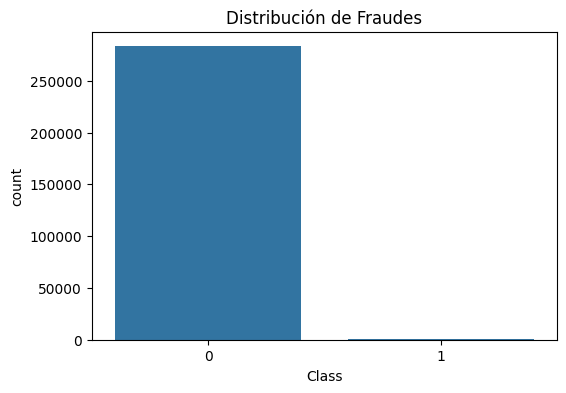

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Distribución de Fraudes")

plt.savefig(
    "../reports/distribucion_fraudes.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Por lo anterior podemos darnos cuenta que el dataset está desbalancedo ya que existen muchísimas transacciones normales

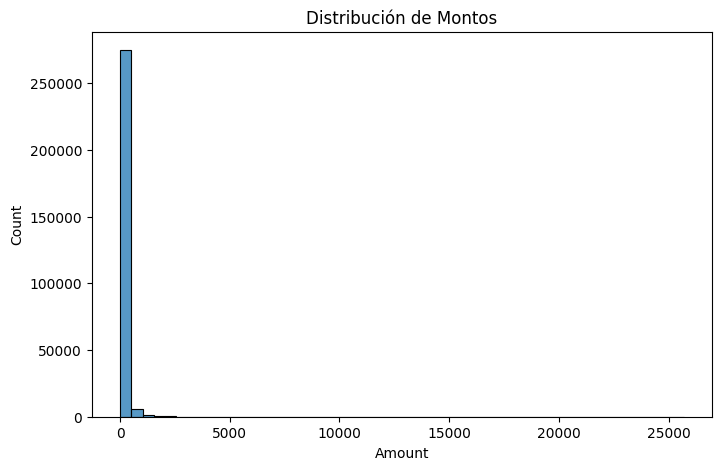

In [40]:
# procedemos a ver las cantidades exactas
df['Class'].value_counts()

# miramos la distribucion de montos
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Distribución de Montos")

plt.savefig(
    "../reports/distribucion_montos.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

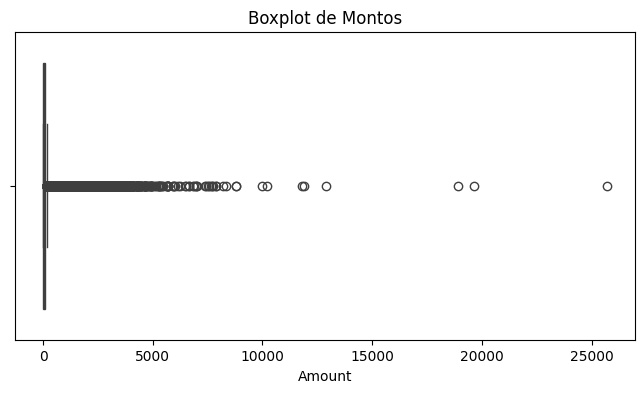

In [38]:
plt.figure(figsize=(8,4))

# miramos ahora un boxplot de los montos
sns.boxplot(x=df['Amount']) 

plt.title("Boxplot de Montos") 

plt.savefig(
    "../reports/boxplot_montos.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

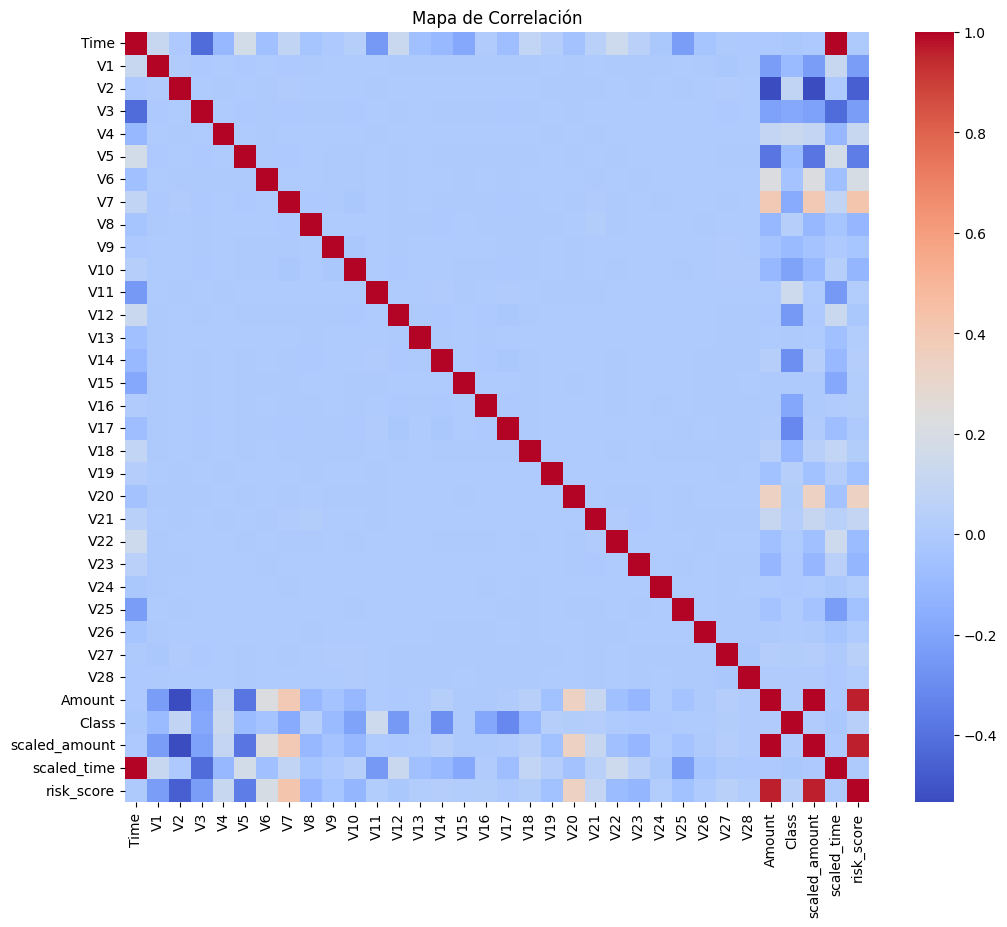

In [39]:
# hacemos las correlaciones
plt.figure(figsize=(12,10)) 

sns.heatmap( 
    df.corr(), 
    cmap='coolwarm' 
) 

plt.title("Mapa de Correlación") 

plt.savefig(
    "../reports/heatmap_correlacion.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Aquí separamos el fraude del no fraude

In [29]:
fraud = df[df['Class'] == 1] 
normal = df[df['Class'] == 0]

Comparamos los montos promedio

In [10]:
fraud['Amount'].mean() 
normal['Amount'].mean()

np.float64(88.41357475472458)

Aquí vamos ahora con el procesamiento oficial

Creamos el scaler:

In [35]:
import joblib

amount_scaler = StandardScaler()
time_scaler = StandardScaler()

#Escalamos la columna 'Amount'
df['scaled_amount'] = amount_scaler.fit_transform(
    df['Amount'].values.reshape(-1, 1)
)

#Hacemos scaler también para la columna 'Time'
df['scaled_time'] = time_scaler.fit_transform(
    df['Time'].values.reshape(-1, 1)
)

joblib.dump(amount_scaler, "../models/amount_scaler.pkl")
joblib.dump(time_scaler, "../models/time_scaler.pkl")

['../models/time_scaler.pkl']

In [12]:
# Borramos las columnas originales 'Amount' y 'Time'
df.drop(['Amount', 'Time'], axis=1, inplace=True)

Creamos el dataset de clasificación

In [13]:
#Creamos X e y
X_class = df.drop('Class', axis=1)
y_class = df['Class']

Procedemos con el balanceo de las clases del dataset (para esto aplicamos SMOTE)

In [14]:
smote = SMOTE(random_state=42) 

X_class_resampled, y_class_resampled = smote.fit_resample(
    X_class, 
    y_class 
)

Después de haber hecho las modificaciones verificamos el balanceo (ambas clases deben quedar con cantidades similares)

In [ ]:
pd.Series(y_class_resampled).value_counts()

Class
0    283253
1    283253
Name: count, dtype: int64

Vamos ahora con el Dataset de Regresión

* Creamos la variable objetivo (risk_score)
* Definimos las variables de regresión (X_reg, y_reg)

In [33]:
df['risk_score'] = (
    abs(df['scaled_amount']) * 0.6 +
    df['Class'] * 0.4
) * 100

X_reg = df.drop(['Class', 'risk_score'], axis=1)
y_reg = df['risk_score']

Dividimos en train y test para clasificación (c) y regresión (r)

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_resampled,
    y_class_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_class_resampled
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split( 
    X_reg, 
    y_reg, 
    test_size=0.2, 
    random_state=42,
    stratify=y_reg
)

Procedemos a exportar los datasets finales guardando los CSVs

In [20]:
#Para clasificación
X_train_c.to_csv("../data/X_train_class.csv", index=False)
X_test_c.to_csv("../data/X_test_class.csv", index=False)
y_train_c.to_csv("../data/y_train_class.csv", index=False)
y_test_c.to_csv("../data/y_test_class.csv", index=False)

#Para regresión
X_train_r.to_csv("../data/X_train_reg.csv", index=False)
X_test_r.to_csv("../data/X_test_reg.csv", index=False)
y_train_r.to_csv("../data/y_train_reg.csv", index=False)
y_test_r.to_csv("../data/y_test_reg.csv", index=False)

Guardamos el dataset procesado completo

In [34]:
df.to_csv("../data/processed_creditcard.csv", index=False)